# Exercise 004

<a href="https://colab.research.google.com/github/FAIRChemistry/PythonProgramming2025/blob/master/exercises/Exercise004.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Please execute this cell to download the necessary data
!wget https://github.com/JR-1991/PythonProgramming2025/raw/master/data/gc_len_data.csv

--2026-05-06 12:52:53--  https://github.com/JR-1991/PythonProgramming2025/raw/master/data/gc_len_data.csv
Resolving github.com (github.com)... 140.82.113.3
Connecting to github.com (github.com)|140.82.113.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/JR-1991/PythonProgramming2025/master/data/gc_len_data.csv [following]
--2026-05-06 12:52:54--  https://raw.githubusercontent.com/JR-1991/PythonProgramming2025/master/data/gc_len_data.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3663624 (3.5M) [text/plain]
Saving to: ‘gc_len_data.csv’

gc_len_data.csv     100%[===================>]   3.49M  --.-KB/s    in 0.07s   

2026-05-06 12:52:54 (51.2 MB/s) - ‘gc_len_data.csv’ saved [3663624/3663624

In [2]:
# Please execute this cell to install the necessary packages
%pip install seaborn matplotlib pandas scikit-learn

## Visualisation of Distributions #1

Read the CSV file `gc_len_data.csv` using the Pandas method `pd.read_csv(path)` and store the result in `DataFrame` in variable `df`. Now use `seaborn` or `matplotlib` to visualize the distribution of all seqeunce lengths found in column `lens`.

**Tips**

> * Importing a package is done via `import package` where package is substituted with the name of the package you want to import. You can also rename a package by using``import package as renamed` where renamed is the new with which you can use the pckage.
> * By convention, `pandas` is always imported as `pd` and `seaborn` as `sns`
> Seaborn allows you to directly use a Pandas `DataFrame` object (stored in variable `df`). In the following is a usage example:

**Example**

Please refer to our [notes](https://jr-1991.github.io/PythonProgrammingBio24/notes/Seminar_004/) for an in-depth example.

```python
# Seaborn - We pass in the data and specify which column to use
sns.countplot(x="a_column", data=df)
```


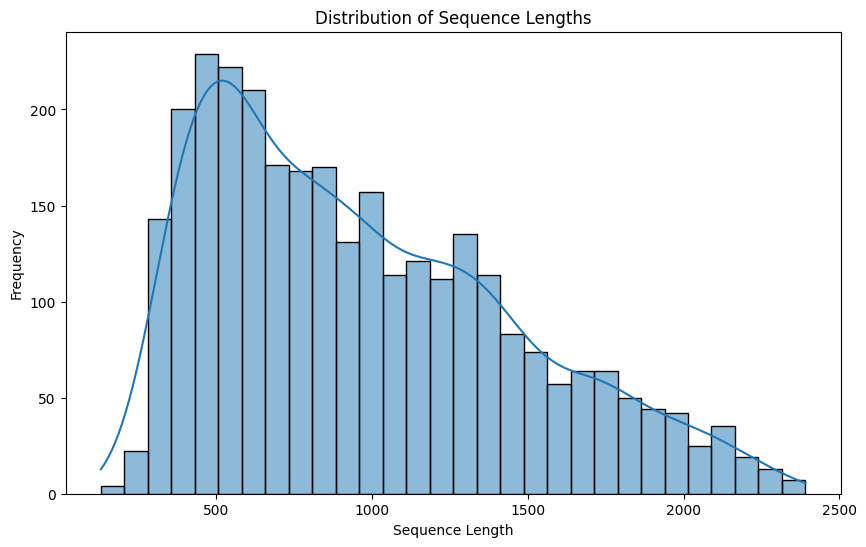

In [3]:
# 1. Import the necessary packages
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 2. Read the CSV file into a Pandas DataFrame
# Make sure 'gc_len_data.csv' is in the same directory as your script
df = pd.read_csv('gc_len_data.csv')

# 3. Visualize the distribution
# Set the size of the figure for better readability
plt.figure(figsize=(10, 6))

# OPTION A: Using histplot (Recommended for a wide range of numerical lengths)
sns.histplot(data=df, x="lens", bins=30, kde=True)
plt.title("Distribution of Sequence Lengths")
plt.xlabel("Sequence Length")
plt.ylabel("Frequency")

# OPTION B: Using countplot (Use this if you have very few unique length values, as per your tip)
# sns.countplot(data=df, x="lens")
# plt.title("Count of Sequence Lengths")

# 4. Display the plot
plt.show()

### Coloration by class

Repeat the visualization, but now color the distribution in relation to the organism. Which conclusions can you gather from the new plot?

**Tips**

> * Some methods found in Seaborns have an argument with which you can specifiy to colour by a specific column. These can be categorical or numerical.
> * Use the argument `multiple` to specifiy how to handle multiple categories in Seaborn's `histplot` or `kdeplot`. See the [documentation](https://seaborn.pydata.org/api.html) to learn more.

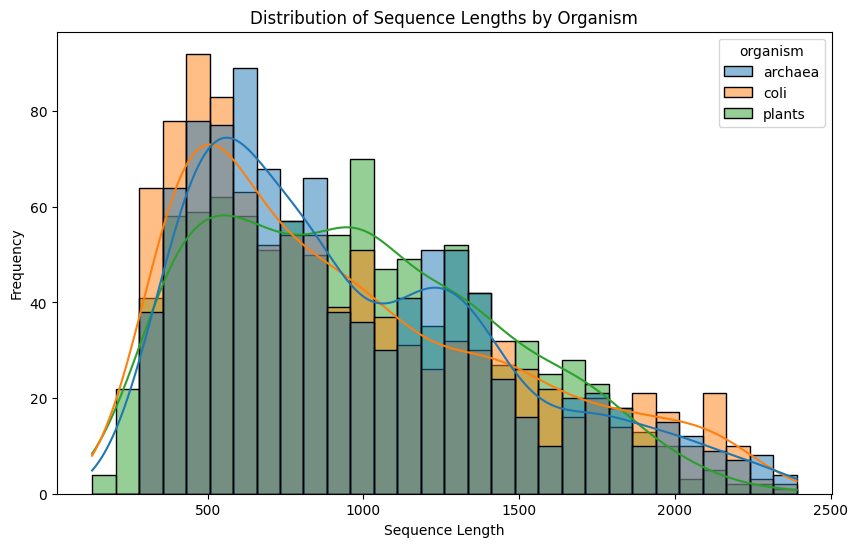

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Read the dataset
df = pd.read_csv('gc_len_data.csv')

# 2. Set up the figure size
plt.figure(figsize=(10, 6))

# 3. Create the histogram colored by organism
# 'hue' colors the data by the organism category
# 'multiple="layer"' overlaps them with transparency.
# You can also try multiple="stack" or multiple="dodge"
sns.histplot(
    data=df,
    x="lens",
    hue="organism",
    multiple="layer",
    bins=30,
    kde=True,
    alpha=0.5 # Adjusts transparency so you can see overlapping distributions
)

# 4. Add labels and title
plt.title("Distribution of Sequence Lengths by Organism")
plt.xlabel("Sequence Length")
plt.ylabel("Frequency")

# 5. Show the plot
plt.show()

## Visualisation of Distributions #2

Repeat the first exercise now for the gc content using the column `gc`. Can you detect a trend?

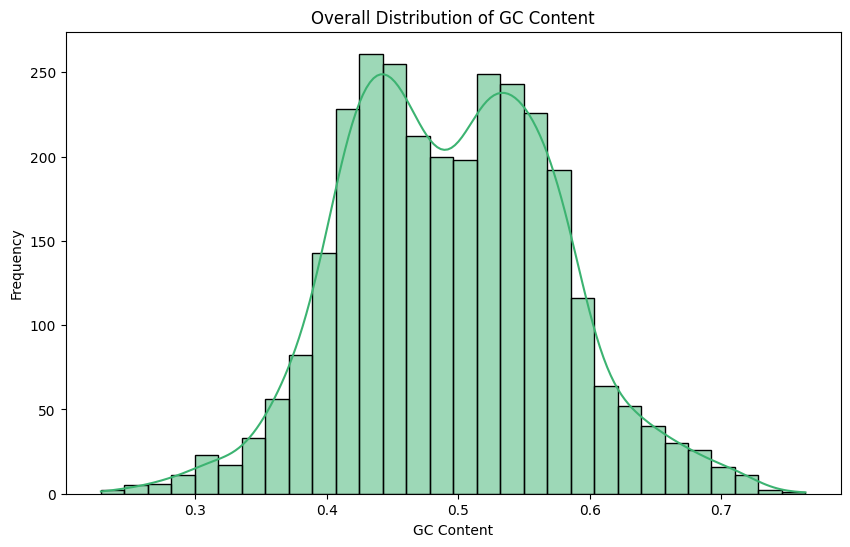

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming you already have your DataFrame loaded as 'df' from previous cells
# If not, uncomment the next line:
# df = pd.read_csv('gc_len_data.csv')

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x="gc", bins=30, kde=True, color="mediumseagreen")
plt.title("Overall Distribution of GC Content")
plt.xlabel("GC Content")
plt.ylabel("Frequency")
plt.show()

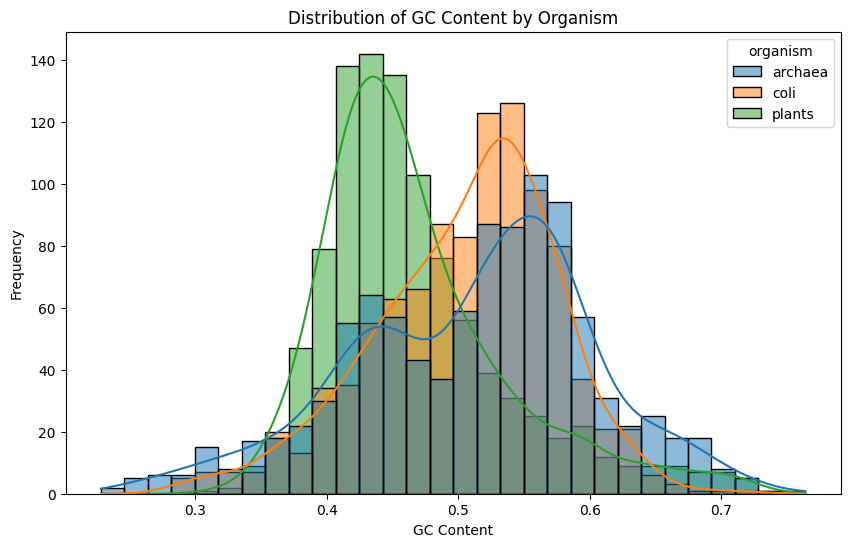

In [6]:
plt.figure(figsize=(10, 6))
# Using 'hue' to separate by organism, and 'multiple="layer"' to overlap them
sns.histplot(data=df, x="gc", hue="organism", multiple="layer", bins=30, kde=True, alpha=0.5)
plt.title("Distribution of GC Content by Organism")
plt.xlabel("GC Content")
plt.ylabel("Frequency")
plt.show()

## Visualisation of bivariate data

In many of our applications and experiments, we want to understand how two features are related to each other. For example, we might want to examine how two variables are correlated in order to develop a hypothesis. In addition to using a quantitative measure like the "R-Squared" value, it can be helpful to create a graph that displays the relationship between the two variables.

Calculate the Correlation Matrix of dataset `df` and print the result. Now visualize both columns `gc` and `lens` in a single plot.

**Tips**

> * The example [gallery](https://seaborn.pydata.org/examples/index.html) of Seaborn can be very inspiring!
> * Pandas can calculate a lot of statistic too. See [here](https://pandas.pydata.org/docs/getting_started/intro_tutorials/06_calculate_statistics.html#) and [here](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corr.html)

--- Correlation Matrix ---
          lens        gc       ATA       ATC       ATT       ATG       ACA  \
lens  1.000000 -0.073403  0.035202  0.082873  0.049099 -0.112150  0.020047   
gc   -0.073403  1.000000 -0.536402 -0.028641 -0.659178 -0.172720 -0.224356   
ATA   0.035202 -0.536402  1.000000  0.063332  0.337361  0.152150  0.139217   
ATC   0.082873 -0.028641  0.063332  1.000000  0.074827  0.121556 -0.088978   
ATT   0.049099 -0.659178  0.337361  0.074827  1.000000  0.100253  0.062093   
...        ...       ...       ...       ...       ...       ...       ...   
TAG  -0.116276 -0.035002  0.141997 -0.024989 -0.106750 -0.010640 -0.031593   
TGC  -0.081650  0.239730 -0.017431  0.062315 -0.160434 -0.100399 -0.032637   
TGT  -0.058079 -0.179582  0.102792 -0.079825  0.088574 -0.066854  0.060601   
TGA  -0.041207  0.116194  0.068478 -0.135901 -0.212920 -0.064704  0.109118   
TGG  -0.022535  0.248143 -0.066099 -0.118146 -0.229491  0.004743  0.035112   

           ACC       ACG       ACT  

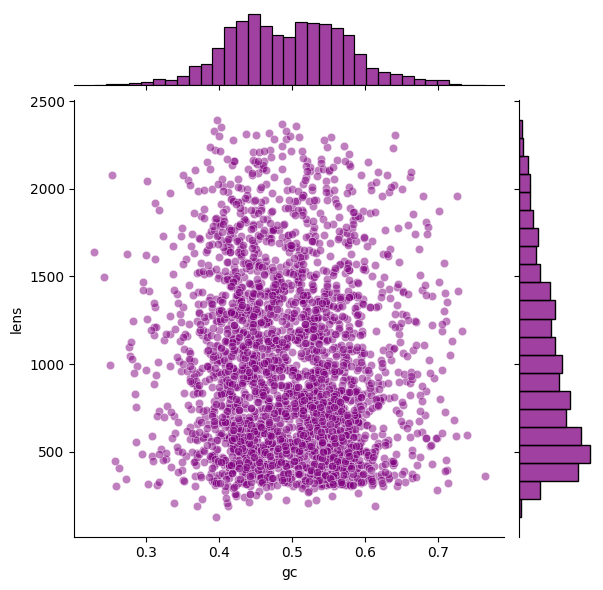

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming 'df' is already loaded in your environment from the previous steps
# df = pd.read_csv('gc_len_data.csv')

# 1. Calculate and print the Correlation Matrix
# Using numeric_only=True ensures we don't get errors from text columns like 'organism'
correlation_matrix = df.corr(numeric_only=True)
print("--- Correlation Matrix ---")
print(correlation_matrix)
print("\n")

# 2. Visualize both 'gc' and 'lens' in a single plot
# sns.jointplot is ideal for bivariate data visualization
sns.jointplot(
    data=df,
    x="gc",
    y="lens",
    kind="scatter", # You can also try "kde" or "hex" for dense data
    alpha=0.5,      # Transparency helps visualize overlapping points
    color="purple"
)

# Display the plot
plt.show()

## Multidimensional data

It's not uncommon for data to have more columns than we can easily comprehend in our three-dimensional world. In these cases, we can use techniques like dimensionality reduction and visualization to help us understand the data better. One of the most popular methods for dimensionality reduction is called [Principle Component Analysis](https://en.wikipedia.org/wiki/Principal_component_analysis) (PCA). This statistical technique helps us identify the components that explain most of the variation in the data.

To use PCA, we need to utilize a module called `scikit-learn`, which also contains many other machine learning algorithms. Since the `df` dataset comprises not only `gc` and `lens` but also individual codon usage, we can use PCA to demonstrate that our classes are more or less distinctive. To apply PCA to the dataset, please make use of the provided `pca` function.

In [8]:
# Execute this cell to use the function

import pandas as pd

from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler


def pca(data: pd.DataFrame) -> pd.DataFrame:
    """Takes a DataFrame and calculates the first two principle components

    Args:
        data (pd.DataFrame): The data used to gather the PCs

    Returns:
        pd.DataFrame: The resulting PCA data
    """

    scaler = MinMaxScaler()
    data = scaler.fit_transform(data.select_dtypes(include="number"))

    pcs = PCA(n_components=2).fit_transform(data)

    return pd.DataFrame({"PC1": pcs[:, 0], "PC2": pcs[:, 1]})

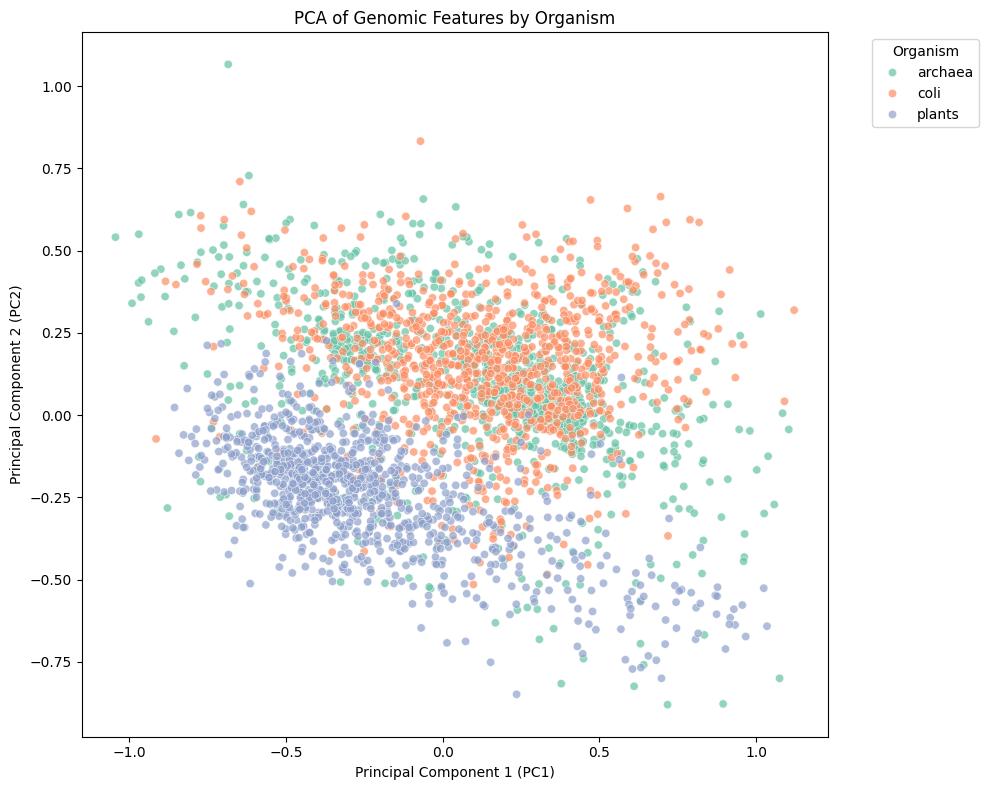

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Apply the provided pca function to your dataset
pca_df = pca(df)

# 2. Add the 'organism' column back to the new PCA DataFrame
# (Make sure 'df' is your original DataFrame containing the 'organism' column)
pca_df['organism'] = df['organism']

# 3. Visualize the Principal Components
plt.figure(figsize=(10, 8))

# A scatterplot is standard for PCA visualization
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="organism",
    alpha=0.7,
    palette="Set2" # Using a distinct color palette helps separate the classes
)

# 4. Format the plot
plt.title("PCA of Genomic Features by Organism")
plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")

# Move the legend outside the plot so it doesn't cover data points
plt.legend(title="Organism", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Display the plot
plt.show()